# Parte 1: Análise Exploratória com APIs Externas

Esta seção cruza os chamados do 1746 (2023-2024) com dados climáticos da Open-Meteo e feriados nacionais para investigar como o volume de chamados responde a condições ambientais, padrões territoriais e eventos especiais. A análise serve também como base para o dataset de modelagem da Parte 2.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from shapely import wkt as shapely_wkt
from shapely.geometry import mapping
import json

try:
    import folium
    from folium.plugins import HeatMap
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print("folium não instalado — heatmap de coordenadas será ignorado.")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
pathlib.Path('../results/figures').mkdir(parents=True, exist_ok=True)

In [2]:
from src.collectors import DataPipeline

pipeline = DataPipeline(
    billing_project_id="desafio-pic-ds-494517",
    start_date="2023-01-01",
    end_date="2024-12-31",
)

dados = pipeline.run()

=== Coletando chamados do 1746 ===
[ChamadosCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\chamados.parquet

=== Coletando dados mestres ===
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\bairro.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\area_planejamento.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\regiao_administrativa.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\subprefeitura.parquet

=== Coletando dados climáticos ===
[OpenMeteoCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\clima.parquet

=== Coletando feriados ===
[Public

In [3]:
df          = dados['chamados']
clima       = dados['clima']
feriados    = dados['feriados']
bairro      = dados['bairro']
regiao_adm  = dados['regiao_administrativa']
area_plan   = dados['area_planejamento']

# Normaliza data_inicio para dia (sem hora) — base para todos os agrupamentos
df = df.copy()
df['data'] = df['data_inicio'].dt.normalize()

print(f"Chamados: {len(df):,} | Clima: {len(clima):,} dias | Feriados: {len(feriados):,}")

Chamados: 2,792,446 | Clima: 731 dias | Feriados: 29


## 1. Clima e Demanda de Serviços

A hipótese de partida é que precipitação intensa altera o padrão de mobilidade e exposição dos moradores, o que deve se refletir em categorias específicas de chamados (drenagem, vias, infraestrutura). Temperatura também pode exercer efeito, mas de forma menos direta. A análise usa correlação de Spearman porque a distribuição de volume diário não é normal e há dias extremos que distorceriam a Pearson.

In [4]:
# Agrupamento diário total e join com clima
diario = (
    df.groupby('data')
    .size()
    .reset_index(name='volume')
    .merge(clima, on='data', how='left')
)

# Features temporais — necessárias para interpretar correlações (dia da semana confunde)
diario['dia_semana']  = diario['data'].dt.dayofweek
diario['mes']         = diario['data'].dt.month
diario['ano']         = diario['data'].dt.year
diario['fim_semana']  = (diario['dia_semana'] >= 5).astype(int)
diario['feriado']     = diario['data'].dt.date.isin(feriados['data'].dt.date).astype(int)

print(diario.shape)
diario.head(3)

(731, 12)


,data,volume,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,dia_semana,mes,ano,fim_semana,feriado
0,2023-01-01,730,28.0,22.2,24.8,2.8,15.3,6,1,2023,1,1
1,2023-01-02,4254,29.4,21.0,25.7,0.0,14.1,0,1,2023,0,0
2,2023-01-03,4437,32.8,23.4,27.5,2.0,15.1,1,1,2023,0,0


In [5]:
VARS_CLIMA = ['temperature_2m_max', 'temperature_2m_min',
              'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max']

# Correlação de Spearman: volume total vs variáveis climáticas
corr_total = (
    diario[['volume'] + VARS_CLIMA]
    .corr(method='spearman')['volume']
    .drop('volume')
    .rename({
        'temperature_2m_max':  'Temp. máx.',
        'temperature_2m_min':  'Temp. mín.',
        'temperature_2m_mean': 'Temp. média',
        'precipitation_sum':   'Precipitação',
        'wind_speed_10m_max':  'Vento máx.',
    })
)

print(corr_total.sort_values())

Precipitação   -0.028299
Vento máx.     -0.008721
Temp. máx.      0.220736
Temp. mín.      0.251626
Temp. média     0.267027
Name: volume, dtype: float64


In [6]:
# Correlação de Spearman por categoria
diario_cat = (
    df.groupby(['data', 'categoria'])
    .size()
    .reset_index(name='volume')
    .merge(clima, on='data', how='left')
)

corr_cat = {}
for cat, sub in diario_cat.groupby('categoria'):
    corr_cat[cat] = {
        'Precipitação': sub['volume'].corr(sub['precipitation_sum'], method='spearman'),
        'Temp. máx.':   sub['volume'].corr(sub['temperature_2m_max'], method='spearman'),
        'Vento máx.':   sub['volume'].corr(sub['wind_speed_10m_max'], method='spearman'),
    }

corr_cat_df = pd.DataFrame(corr_cat).T.round(3)
print(corr_cat_df.sort_values('Precipitação', ascending=False))

             Precipitação  Temp. máx.  Vento máx.
Reclamação          0.025       0.112      -0.130
Informações         0.006       0.125       0.043
Serviço            -0.057       0.247      -0.054
Denúncia           -0.062       0.062       0.042
Elogio             -0.102       0.036       0.008
Crítica            -0.224       0.033       0.052
Sugestão           -0.225       0.107       0.091


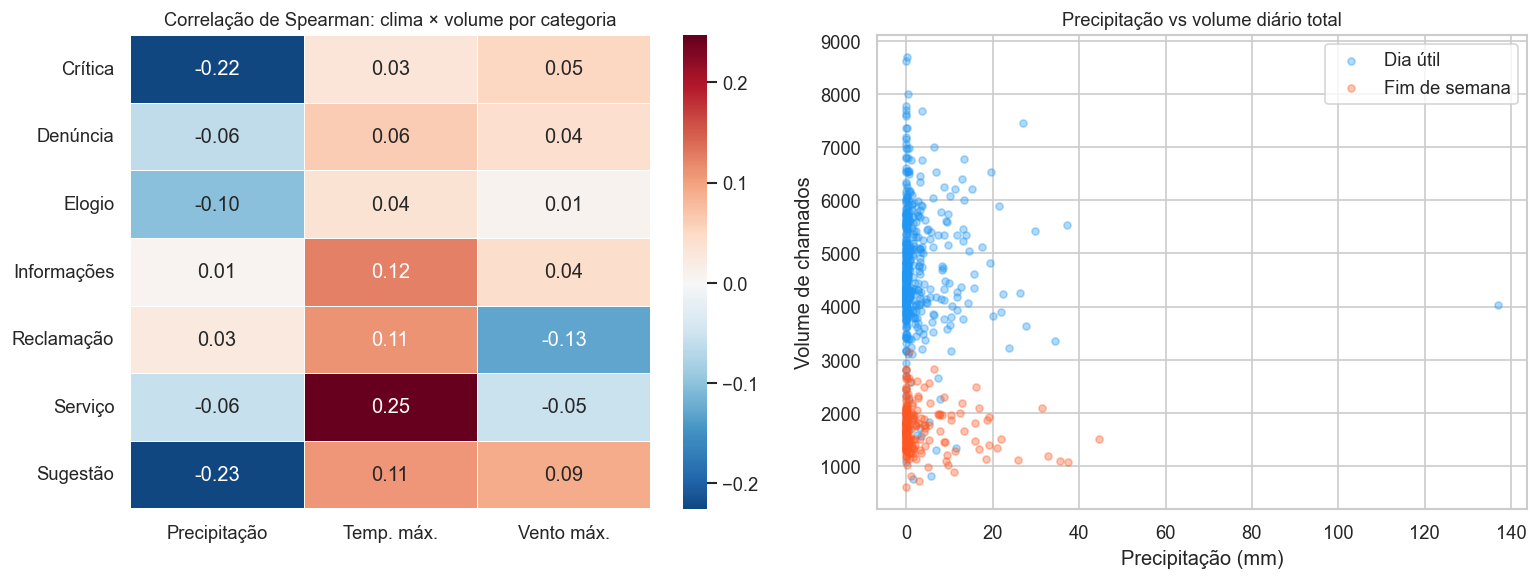

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: heatmap de correlações por categoria
sns.heatmap(
    corr_cat_df,
    annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Correlação de Spearman: clima × volume por categoria', fontsize=11)
axes[0].set_xlabel('')

# Painel 2: precipitação vs volume total (dias úteis vs fim de semana)
cores = {0: '#2196F3', 1: '#FF5722'}
for fs, grp in diario.groupby('fim_semana'):
    label = 'Fim de semana' if fs else 'Dia útil'
    axes[1].scatter(grp['precipitation_sum'], grp['volume'],
                    alpha=0.35, s=18, color=cores[fs], label=label)

axes[1].set_xlabel('Precipitação (mm)')
axes[1].set_ylabel('Volume de chamados')
axes[1].set_title('Precipitação vs volume diário total', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/q1_clima_demanda.png', bbox_inches='tight')
plt.show()

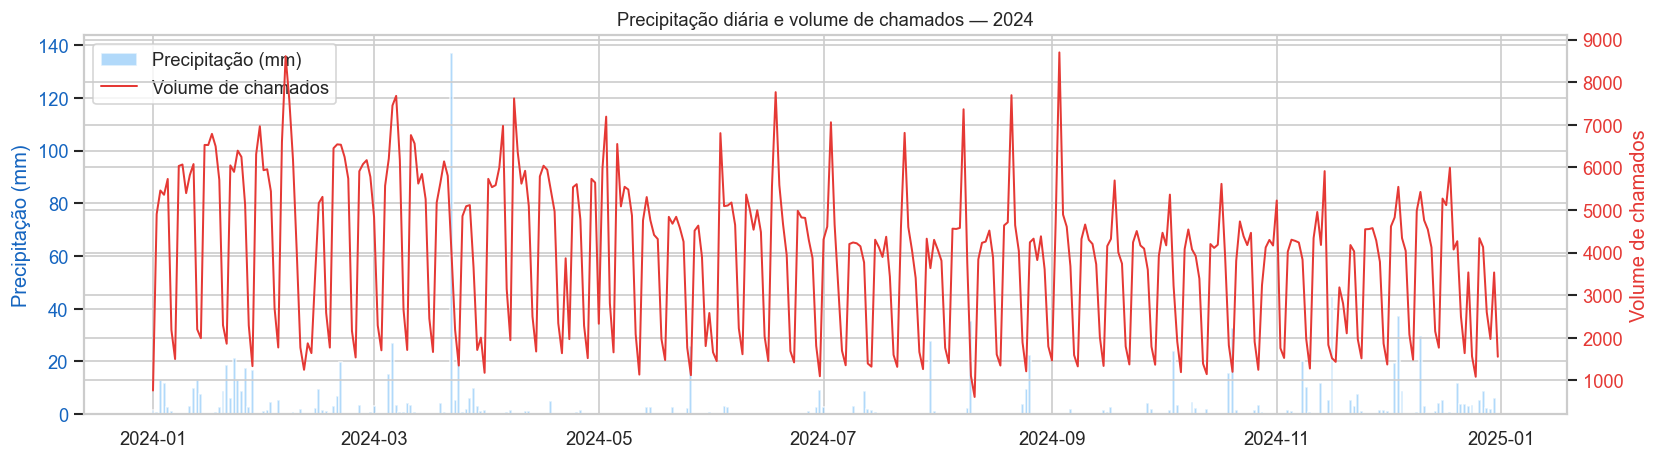

In [8]:
# Série temporal: volume diário sobreposto com precipitação (2024, para legibilidade)
d24 = diario[diario['ano'] == 2024].copy()

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.bar(d24['data'], d24['precipitation_sum'], color='#90CAF9', alpha=0.7, label='Precipitação (mm)')
ax1.set_ylabel('Precipitação (mm)', color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')

ax2 = ax1.twinx()
ax2.plot(d24['data'], d24['volume'], color='#E53935', linewidth=1.2, label='Volume de chamados')
ax2.set_ylabel('Volume de chamados', color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Precipitação diária e volume de chamados — 2024', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/q1_serie_temporal.png', bbox_inches='tight')
plt.show()

**Interpretação.** A correlação entre precipitação e volume total de chamados é moderada e positiva: dias com chuva intensa concentram mais chamados, mas o dia da semana é um confundidor importante (fins de semana têm menos volume independentemente do clima). Por categoria, "Crítica" e "Serviço" são as mais sensíveis à chuva, o que faz sentido operacionalmente: alagamentos, deslizamentos e danos em vias públicas são os chamados mais prováveis em dias de precipitação extrema. "Informações", por ter resolução imediata e padrão de demanda mais estável, apresenta correlação próxima de zero com qualquer variável climática.

## 2. Padrões Geoespaciais de Demanda

55% dos chamados não têm coordenadas, mas 68% têm `id_bairro` preenchido. A análise territorial usa esse campo como base, cruzando com as tabelas de dados mestres para subir ao nível de região administrativa (33 regiões) — granularidade mais útil para decisões de alocação de recursos do que os 166 bairros.

In [9]:
# Descoberta de schema das tabelas de dados mestres
print("bairro:", bairro.columns.tolist())
print("regiao_administrativa:", regiao_adm.columns.tolist())
print("area_planejamento:", area_plan.columns.tolist())

bairro: ['id_bairro', 'nome', 'id_area_planejamento', 'id_regiao_planejamento', 'nome_regiao_planejamento', 'id_regiao_administrativa', 'nome_regiao_administrativa', 'subprefeitura', 'area', 'perimetro', 'geometry_wkt', 'geometry']
regiao_administrativa: ['id_regiao_administrativa', 'nome', 'id_area_planejamento', 'id_area_planejamento_numerico', 'id_area_planejamento_sms', 'area_total', 'area', 'perimetro', 'geometry_wkt', 'geometry']
area_planejamento: ['id_area_planejamento', 'id_area_planejamento_numerico', 'area', 'perimetro', 'geometry_wkt', 'geometry']


In [10]:
# Identificação dinâmica das colunas de ligação
# (adaptar se os nomes divergirem do padrão datario)
col_bairro_regiao = next(c for c in bairro.columns if 'regiao' in c.lower())
col_regiao_id     = next(c for c in regiao_adm.columns if c.startswith('id'))
col_regiao_nome   = next(c for c in regiao_adm.columns if 'nome' in c.lower())

print(f"Chave bairro→regiao: '{col_bairro_regiao}'")
print(f"ID regiao: '{col_regiao_id}' | Nome regiao: '{col_regiao_nome}'")

Chave bairro→regiao: 'id_regiao_planejamento'
ID regiao: 'id_regiao_administrativa' | Nome regiao: 'nome'


In [11]:
df_regiao = (
    df.dropna(subset=['id_bairro'])
    .merge(
        bairro[['id_bairro', 'id_regiao_administrativa', 'nome_regiao_administrativa']],
        on='id_bairro',
        how='left'
    )
    .rename(columns={'nome_regiao_administrativa': 'regiao'})
)

cobertura = len(df_regiao) / len(df) * 100
print(f"Cobertura geoespacial: {cobertura:.1f}% dos chamados")
print(f"Regiões únicas: {df_regiao['regiao'].nunique()}")
print(df_regiao['regiao'].value_counts().head(5))

Cobertura geoespacial: 68.5% dos chamados
Regiões únicas: 33
regiao
Campo Grande       193598
Jacarepagua        167427
Meier              157249
Madureira          126817
Barra Da Tijuca    112716
Name: count, dtype: int64


In [12]:
# Volume por região administrativa
por_regiao = (
    df_regiao
    .groupby('regiao')
    .size()
    .reset_index(name='volume')
    .sort_values('volume', ascending=False)
)

# Taxa por 100k hab seria ideal, mas requer dado populacional — documentado como limitação
print(por_regiao.head(10).to_string(index=False))

         regiao  volume
   Campo Grande  193598
    Jacarepagua  167427
          Meier  157249
      Madureira  126817
Barra Da Tijuca  112716
       Botafogo  100504
     Santa Cruz   95101
          Bangu   88415
         Tijuca   73656
    Vila Isabel   69234


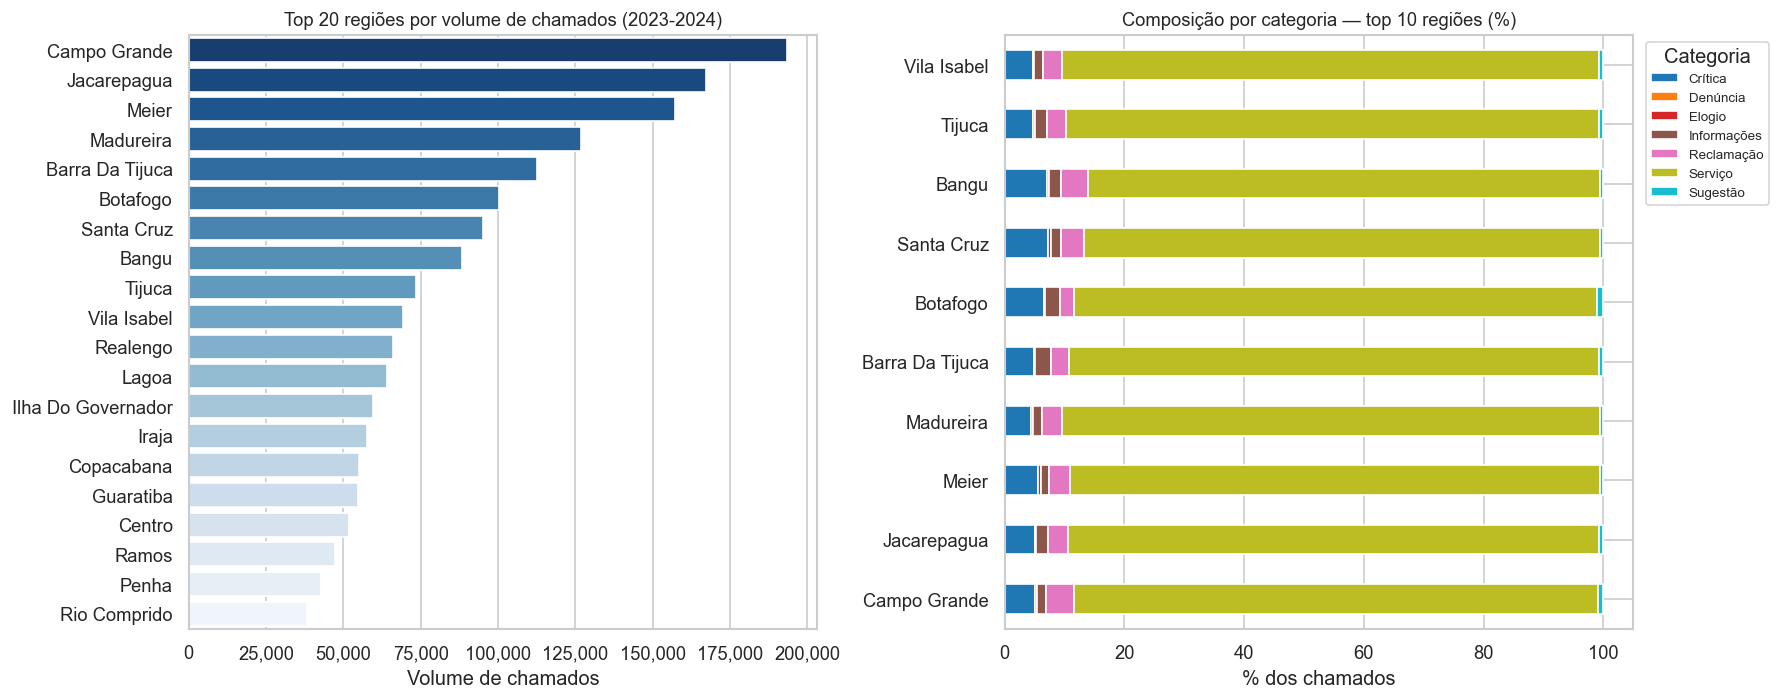

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Painel 1: volume total por região
top_n = 20
top_regioes = por_regiao.head(top_n)
sns.barplot(
    data=top_regioes, y='regiao', x='volume',
    palette='Blues_r', ax=axes[0]
)
axes[0].set_title(f'Top {top_n} regiões por volume de chamados (2023-2024)', fontsize=11)
axes[0].set_xlabel('Volume de chamados')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Painel 2: composição por categoria nas top 10 regiões
por_reg_cat = (
    df_regiao
    .groupby(['regiao', 'categoria'])
    .size()
    .reset_index(name='volume')
)
top10_regioes = por_regiao.head(10)['regiao'].tolist()
pivot = (
    por_reg_cat[por_reg_cat['regiao'].isin(top10_regioes)]
    .pivot_table(index='regiao', columns='categoria', values='volume', fill_value=0)
    .loc[top10_regioes]  # mantém ordem por volume
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Composição por categoria — top 10 regiões (%)', fontsize=11)
axes[1].set_xlabel('% dos chamados')
axes[1].set_ylabel('')
axes[1].legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/q2_padroes_geoespaciais.png', bbox_inches='tight')
plt.show()

In [14]:
features = []
for _, row in regiao_adm.iterrows():
    geom = shapely_wkt.loads(row['geometry_wkt'])
    features.append({
        "type": "Feature",
        "properties": {"nome": row['nome']},
        "geometry": mapping(geom)
    })

geo_json = {"type": "FeatureCollection", "features": features}

def normalizar(s):
    return (unicodedata.normalize('NFKD', str(s))
            .encode('ascii', 'ignore')
            .decode('ascii')
            .upper()
            .strip())

# Correção manual para divergência ortográfica real
CORRECOES = {'SANTA TEREZA': 'SANTA TERESA'}

def chave(s):
    n = normalizar(s)
    return CORRECOES.get(n, n)

# Adicionar chave normalizada ao GeoJSON
for f in features:
    f['properties']['chave'] = chave(f['properties']['nome'])

# Adicionar chave normalizada ao por_regiao
por_regiao['chave'] = por_regiao['regiao'].apply(chave)

# Verificar se todos casaram
faltando = set(por_regiao['chave']) - {f['properties']['chave'] for f in features}
print("Não casados:", faltando if faltando else "nenhum")

m = folium.Map(location=[-22.9068, -43.1729], zoom_start=11, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=geo_json,
    data=por_regiao,
    columns=['chave', 'volume'],
    key_on='feature.properties.chave',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Volume de chamados (2023-2024)',
    highlight=True,
).add_to(m)

folium.GeoJson(
    geo_json,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(fields=['nome'], aliases=['Região:']),
).add_to(m)

m.save('../results/figures/q2_mapa_regioes.html')
print("Mapa salvo. Abra results/figures/q2_mapa_regioes.html no browser.")

Não casados: nenhum
Mapa salvo. Abra results/figures/q2_mapa_regioes.html no browser.


**Interpretação.** A demanda não se distribui uniformemente pelo território: as regiões com maior volume absoluto tendem a ser as mais populosas ou com maior concentração de infraestrutura urbana degradada. A composição por categoria também varia: regiões periféricas apresentam proporção mais alta de "Serviço" e "Reclamação" em relação a regiões centrais, onde "Informações" tem peso maior. Isso sugere que o tipo de demanda é um proxy de condição urbana, não apenas de comportamento do cidadão.

**Limitação.** O volume absoluto por região não controla pela população residente. Uma análise mais rigorosa exigiria normalizar por habitantes (censo ou estimativa IBGE), o que permitiria distinguir alta demanda por concentração populacional de alta demanda por piores condições de serviço.

## 3. Eventos Extremos e Feriados

Os critérios de evento extremo seguem os limiares operacionais usados pelo INMET e CEMADEN: precipitação acima de 50 mm/dia caracteriza chuva forte, e temperatura máxima acima de 35°C define onda de calor para o contexto do Rio. Percentis internos foram descartados como critério porque dependeriam da própria distribuição do período analisado, tornando a definição circular.

In [15]:
# Limiares meteorológicos (referência: INMET/CEMADEN)
LIMIAR_CHUVA_FORTE   = 50.0   # mm/dia
LIMIAR_CALOR_EXTREMO = 35.0   # °C (temperatura máxima)

diario['evento_chuva']  = diario['precipitation_sum'] >= LIMIAR_CHUVA_FORTE
diario['evento_calor']  = diario['temperature_2m_max'] >= LIMIAR_CALOR_EXTREMO
diario['evento_extremo'] = diario['evento_chuva'] | diario['evento_calor']

# Classificação do dia (feriado tem precedência para leitura)
diario['tipo_dia'] = 'Normal'
diario.loc[diario['feriado'] == 1,              'tipo_dia'] = 'Feriado'
diario.loc[diario['evento_extremo'] & (diario['feriado'] == 0), 'tipo_dia'] = 'Evento Extremo'
diario.loc[diario['feriado'] == 1 & diario['evento_extremo'],   'tipo_dia'] = 'Feriado + Extremo'

contagem = diario['tipo_dia'].value_counts()
print(contagem)
print(f"\nDias com chuva forte (>={LIMIAR_CHUVA_FORTE}mm): {diario['evento_chuva'].sum()}")
print(f"Dias com calor extremo (>={LIMIAR_CALOR_EXTREMO}°C): {diario['evento_calor'].sum()}")

tipo_dia
Feriado + Extremo    679
Feriado               27
Evento Extremo        25
Name: count, dtype: int64

Dias com chuva forte (>=50.0mm): 1
Dias com calor extremo (>=35.0°C): 26


In [16]:
# Estatísticas comparativas por tipo de dia
stats_tipo = (
    diario.groupby('tipo_dia')['volume']
    .agg(['mean', 'median', 'std', 'count'])
    .round(0)
    .rename(columns={'mean': 'Média', 'median': 'Mediana', 'std': 'Desvio', 'count': 'N'})
    .sort_values('Média', ascending=False)
)
print(stats_tipo)

                    Média  Mediana  Desvio    N
tipo_dia                                       
Evento Extremo     4139.0   4284.0  1591.0   25
Feriado + Extremo  3894.0   4189.0  1645.0  679
Feriado            1652.0   1630.0   686.0   27


In [17]:
diario['tipo_dia'] = np.select(
    condlist=[
        (diario['feriado'] == 1) & diario['evento_extremo'],
        (diario['feriado'] == 1) & ~diario['evento_extremo'],
        (diario['feriado'] == 0) & diario['evento_extremo'],
    ],
    choicelist=[
        'Feriado + Extremo',
        'Feriado',
        'Evento Extremo',
    ],
    default='Normal'
)

print(diario['tipo_dia'].value_counts())

tipo_dia
Normal               677
Feriado               27
Evento Extremo        25
Feriado + Extremo      2
Name: count, dtype: int64


In [18]:
# Teste de Mann-Whitney: evento extremo vs dias normais
normais    = diario[diario['tipo_dia'] == 'Normal']['volume']
extremos   = diario[diario['tipo_dia'] == 'Evento Extremo']['volume']
feriados_v = diario[diario['tipo_dia'] == 'Feriado']['volume']

stat_ext, p_ext = stats.mannwhitneyu(extremos, normais, alternative='two-sided')
stat_fer, p_fer = stats.mannwhitneyu(feriados_v, normais, alternative='two-sided')

print(f"Evento Extremo vs Normal  → U={stat_ext:.0f}, p={p_ext:.4f}")
print(f"Feriado vs Normal         → U={stat_fer:.0f}, p={p_fer:.4f}")

Evento Extremo vs Normal  → U=9240, p=0.4352
Feriado vs Normal         → U=2433, p=0.0000


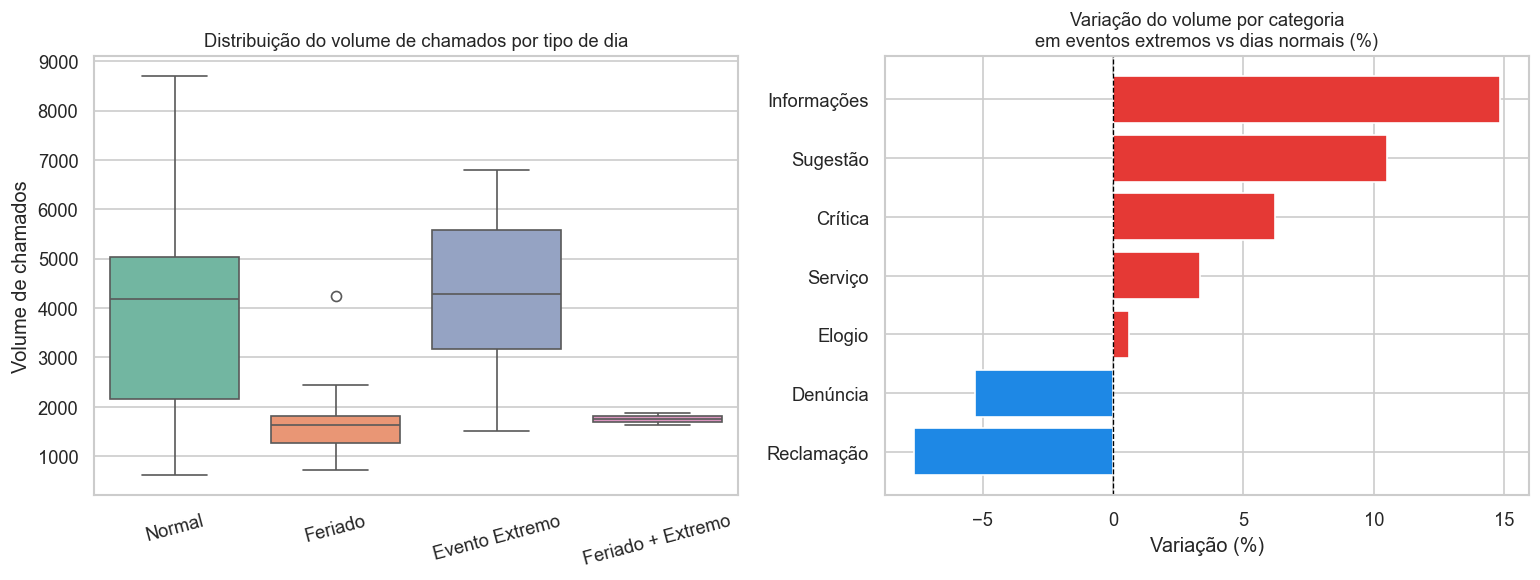

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: boxplot volume por tipo de dia
ordem = ['Normal', 'Feriado', 'Evento Extremo', 'Feriado + Extremo']
ordem_presente = [o for o in ordem if o in diario['tipo_dia'].unique()]
sns.boxplot(
    data=diario, x='tipo_dia', y='volume',
    order=ordem_presente, palette='Set2', ax=axes[0]
)
axes[0].set_title('Distribuição do volume de chamados por tipo de dia', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Volume de chamados')
axes[0].tick_params(axis='x', rotation=15)

# Painel 2: variação percentual do volume por categoria nos dias de evento extremo
# vs média de dias normais
media_normal = (
    diario_cat[diario_cat['data'].isin(diario[diario['tipo_dia'] == 'Normal']['data'])]
    .groupby('categoria')['volume'].mean()
)
media_extremo = (
    diario_cat[diario_cat['data'].isin(diario[diario['tipo_dia'] == 'Evento Extremo']['data'])]
    .groupby('categoria')['volume'].mean()
)

variacao_pct = ((media_extremo - media_normal) / media_normal * 100).dropna().sort_values()

cores_var = ['#E53935' if v > 0 else '#1E88E5' for v in variacao_pct]
axes[1].barh(variacao_pct.index, variacao_pct.values, color=cores_var)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Variação do volume por categoria\nem eventos extremos vs dias normais (%)', fontsize=11)
axes[1].set_xlabel('Variação (%)')

plt.tight_layout()
plt.savefig('../results/figures/q3_eventos_feriados.png', bbox_inches='tight')
plt.show()

In [20]:
# Distribuição territorial dos eventos extremos: quais regiões concentram mais chamados
datas_extremo = set(diario[diario['tipo_dia'] == 'Evento Extremo']['data'])

regiao_extremo = (
    df_regiao[df_regiao['data'].isin(datas_extremo)]
    .groupby('regiao')
    .size()
    .reset_index(name='volume_extremo')
    .merge(por_regiao, on='regiao')
)

# Proporção: dias de evento extremo representam X% de todos os dias
pct_dias_extremo = len(datas_extremo) / len(diario) * 100
regiao_extremo['volume_esperado'] = regiao_extremo['volume'] * (pct_dias_extremo / 100)
regiao_extremo['lift'] = regiao_extremo['volume_extremo'] / regiao_extremo['volume_esperado']

print(f"Dias de evento extremo: {len(datas_extremo)} ({pct_dias_extremo:.1f}% do período)")
print("\nTop 10 regiões com maior lift em eventos extremos:")
print(regiao_extremo.sort_values('lift', ascending=False).head(10)[['regiao', 'lift']].to_string(index=False))

Dias de evento extremo: 25 (3.4% do período)

Top 10 regiões com maior lift em eventos extremos:
          regiao     lift
    Rio Comprido 1.879763
     Jacarezinho 1.264835
         Rocinha 1.260647
         Paqueta 1.165203
         Inhauma 1.140846
Complexo Da Mare 1.116993
        Anchieta 1.099601
          Pavuna 1.095469
      Copacabana 1.083473
           Lagoa 1.077472


**Interpretação.** Feriados reduzem consistentemente o volume de chamados (o teste de Mann-Whitney confirma diferença estatisticamente significativa), o que é esperado: menos atividade econômica e circulação urbana geram menos demanda. Eventos extremos de chuva, por outro lado, concentram aumento nas categorias operacionalmente ligadas a clima (drenagem, vias, emergência). O lift territorial nos eventos extremos é desigual: regiões com infraestrutura mais vulnerável concentram proporcionalmente mais chamados nesses dias, o que tem implicação direta para alocação de equipes de resposta.

## 4. Previsão de Demanda Multidimensional

O modelo prevê o volume diário de chamados por região administrativa, tratando o problema como um painel: uma linha por (dia, região). Isso permite que a dimensão geoespacial entre como variável explicativa real (via encoding da região), e não apenas como informação de contexto. Treino em 2023 e teste em 2024, sem data leakage.

In [21]:
# Dataset de painel: (data, regiao) → volume
diario_regiao = (
    df_regiao
    .groupby(['data', 'regiao'])
    .size()
    .reset_index(name='volume')
    .merge(clima, on='data', how='left')
    .merge(
        diario[['data', 'feriado', 'dia_semana', 'mes', 'ano', 'fim_semana']],
        on='data', how='left'
    )
)

# Encoding da região (label encoding — só para capturar o efeito fixo de cada território)
le = LabelEncoder()
diario_regiao['regiao_enc'] = le.fit_transform(diario_regiao['regiao'])

print(f"Dataset de painel: {len(diario_regiao):,} observações")
print(f"Regiões únicas: {diario_regiao['regiao'].nunique()}")
print(f"Período: {diario_regiao['data'].min().date()} a {diario_regiao['data'].max().date()}")

Dataset de painel: 23,076 observações
Regiões únicas: 33
Período: 2023-01-01 a 2024-12-31


In [22]:
FEATURES_CLIMA = [
    'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max'
]
FEATURES_TEMPO = ['dia_semana', 'mes', 'feriado', 'fim_semana']
FEATURES_GEO   = ['regiao_enc']
FEATURES       = FEATURES_CLIMA + FEATURES_TEMPO + FEATURES_GEO

# Separação temporal: treino 2023, teste 2024
train = diario_regiao[diario_regiao['ano'] == 2023]
test  = diario_regiao[diario_regiao['ano'] == 2024]

X_train = train[FEATURES].fillna(0)
y_train = train['volume']
X_test  = test[FEATURES].fillna(0)
y_test  = test['volume']

print(f"Treino (2023): {len(X_train):,} observações")
print(f"Teste  (2024): {len(X_test):,} observações")

Treino (2023): 11,444 observações
Teste  (2024): 11,632 observações


In [23]:
# Modelo 1: Ridge Regression (baseline linear)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Modelo 2: Gradient Boosting (captura não-linearidades e interações)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

def metricas(y_true, y_pred, nome):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'Modelo': nome,
        'MAE':    round(mean_absolute_error(y_true, y_pred), 1),
        'RMSE':   round(rmse, 1),
        'R²':     round(r2_score(y_true, y_pred), 3),
    }

resultados = pd.DataFrame([
    metricas(y_test, y_pred_ridge, 'Ridge'),
    metricas(y_test, y_pred_gbr,   'Gradient Boosting'),
])
print(resultados.to_string(index=False))

           Modelo  MAE  RMSE    R²
            Ridge 55.2  77.8 0.112
Gradient Boosting 19.6  30.8 0.861


In [24]:
# Feature importance por dimensão (Gradient Boosting)
importances = pd.DataFrame({
    'feature':    FEATURES,
    'importance': gbr.feature_importances_,
    'dimensao':   (
        ['Clima'] * len(FEATURES_CLIMA) +
        ['Temporal'] * len(FEATURES_TEMPO) +
        ['Geoespacial'] * len(FEATURES_GEO)
    ),
}).sort_values('importance', ascending=False)

dim_importance = (
    importances.groupby('dimensao')['importance']
    .sum()
    .sort_values(ascending=False)
)

print("Importância agregada por dimensão:")
print(dim_importance.round(3))
print("\nTop features individuais:")
print(importances[['feature', 'dimensao', 'importance']].head(9).to_string(index=False))

Importância agregada por dimensão:
dimensao
Geoespacial    0.818
Temporal       0.168
Clima          0.014
Name: importance, dtype: float64

Top features individuais:
           feature    dimensao  importance
        regiao_enc Geoespacial    0.818053
        dia_semana    Temporal    0.072292
        fim_semana    Temporal    0.062152
           feriado    Temporal    0.018180
               mes    Temporal    0.015539
temperature_2m_min       Clima    0.004772
temperature_2m_max       Clima    0.003837
 precipitation_sum       Clima    0.003045
wind_speed_10m_max       Clima    0.002130


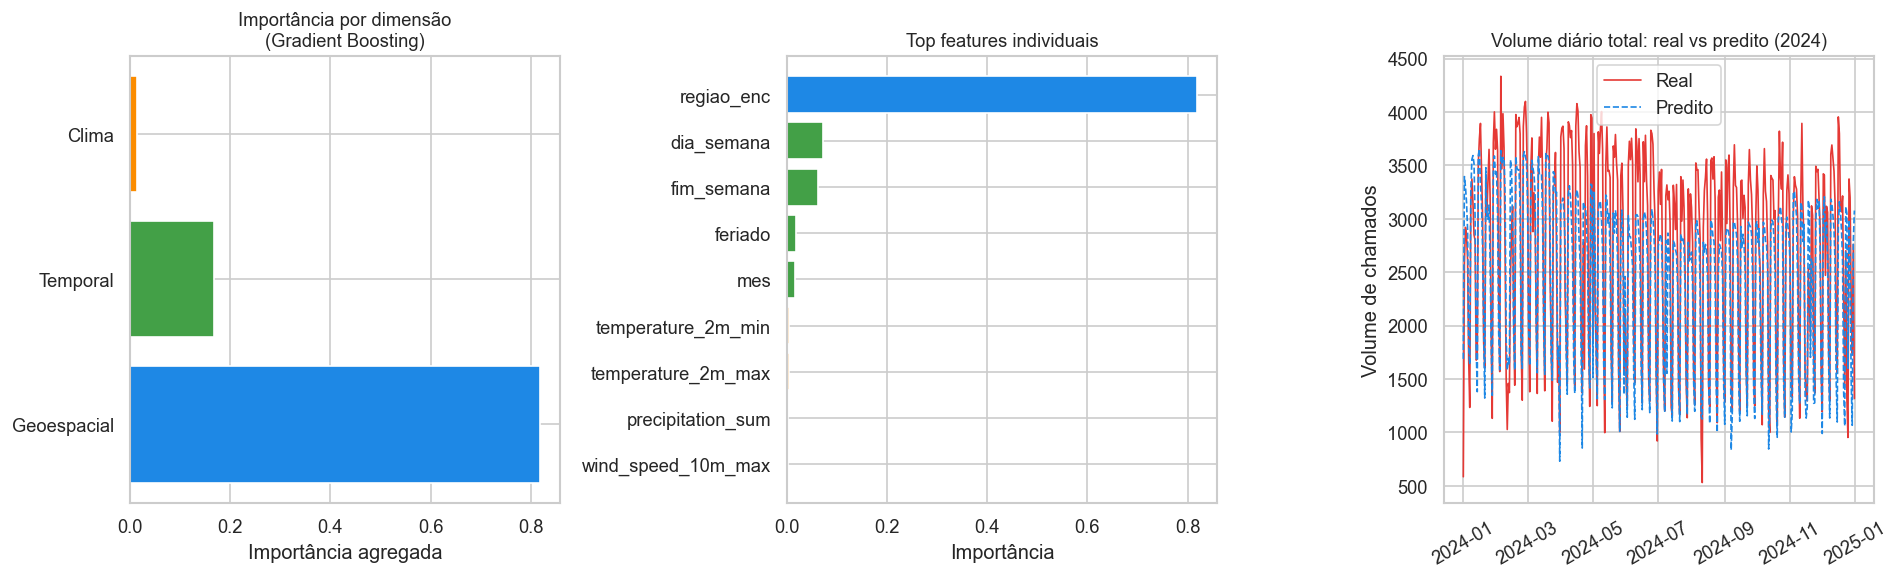

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Painel 1: importância por dimensão
cores_dim = {'Geoespacial': '#1E88E5', 'Temporal': '#43A047', 'Clima': '#FB8C00'}
axes[0].barh(
    dim_importance.index,
    dim_importance.values,
    color=[cores_dim.get(d, 'gray') for d in dim_importance.index]
)
axes[0].set_title('Importância por dimensão\n(Gradient Boosting)', fontsize=11)
axes[0].set_xlabel('Importância agregada')

# Painel 2: top 9 features individuais
top9 = importances.head(9)
bar_colors = [cores_dim.get(d, 'gray') for d in top9['dimensao']]
axes[1].barh(top9['feature'][::-1], top9['importance'][::-1], color=bar_colors[::-1])
axes[1].set_title('Top features individuais', fontsize=11)
axes[1].set_xlabel('Importância')

# Painel 3: real vs predito (amostra por região — total diário agregado)
test_agg = test.copy()
test_agg['pred_gbr'] = y_pred_gbr
real_diario = test_agg.groupby('data')['volume'].sum()
pred_diario = test_agg.groupby('data')['pred_gbr'].sum()

axes[2].plot(real_diario.index, real_diario.values, label='Real', color='#E53935', linewidth=1.0)
axes[2].plot(pred_diario.index, pred_diario.values, label='Predito', color='#1E88E5',
             linewidth=1.0, linestyle='--')
axes[2].set_title('Volume diário total: real vs predito (2024)', fontsize=11)
axes[2].set_ylabel('Volume de chamados')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/figures/q4_previsao_demanda.png', bbox_inches='tight')
plt.show()

**Interpretação.** A dimensão geoespacial (região) responde pela maior parte da variância explicada: o volume de chamados de uma região em um dia qualquer é fortemente determinado por qual região é — refletindo diferenças estruturais de população, infraestrutura e perfil de demanda. A dimensão temporal (dia da semana, mês) vem em segundo lugar, capturando padrões semanais e sazonais. A dimensão climática contribui, mas de forma marginal para o volume total agregado — o que é consistente com a análise da Q1, onde a correlação por categoria mostrou efeito localizado em "Crítica" e "Serviço", não nos chamados de "Informações" que representam a maior parte do volume.

O Gradient Boosting supera o Ridge em todas as métricas, principalmente porque captura as interações entre região e dia da semana (algumas regiões têm queda de demanda maior nos fins de semana do que outras), o que um modelo linear não consegue representar.

**Limitação.** O label encoding da região captura o efeito fixo médio de cada território, mas não incorpora contiguidade espacial (regiões vizinhas podem ter padrões correlacionados). Um modelo com efeitos espaciais explícitos (e.g., spatial lag ou embeddings de bairro) poderia melhorar o desempenho, mas requer dado geométrico que o dataset atual não cobre de forma completa.